# Asset Price Modeling: Main-Text Implementation Notebook

This notebook is the textbook-body version focused on implementation principles.

Goal: move from mathematical model statements to complete, executable Python implementations with figures.

## How to read this notebook

For each model, we follow one pattern:

1. State the model in LaTeX
2. Explain discretization and parameter meaning
3. Implement a full function
4. Run and visualize paths

All stochastic blocks include `seed` for reproducibility.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from quant_edu.asset_price_modeling import fetch_close_prices

plt.style.use("seaborn-v0_8")

## 1) Symmetric Random Walk

Model:

$$
X_j = \begin{cases}
+1, & \mathbb{P}=\tfrac{1}{2} \\n-1, & \mathbb{P}=\tfrac{1}{2}
\end{cases},\qquad
M_k = \sum_{j=1}^{k}X_j, M_0=0.
$$

Implementation principle: generate all increments first, then cumulative sum along time axis.

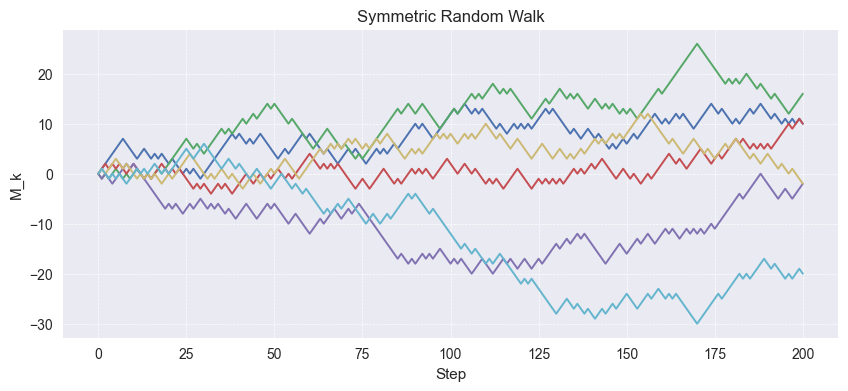

In [2]:
def simulate_symmetric_random_walk_impl(
    n_steps: int,
    n_paths: int = 1,
    start: float = 0.0,
    seed: int | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    increments = rng.choice(np.array([-1.0, 1.0]), size=(n_paths, n_steps))
    cumulative = np.cumsum(increments, axis=1)
    start_col = np.full((n_paths, 1), float(start))
    return np.concatenate([start_col, float(start) + cumulative], axis=1)


rw_paths = simulate_symmetric_random_walk_impl(n_steps=200, n_paths=6, seed=7)

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(rw_paths.shape[0]):
    ax.plot(rw_paths[i], linewidth=1.4)
ax.set_title("Symmetric Random Walk")
ax.set_xlabel("Step")
ax.set_ylabel("M_k")
ax.grid(True, linestyle="--", linewidth=0.5)
plt.show()


## 2) Brownian Motion

Increment law:

$$
W(t_{i+1}) - W(t_i) \sim \mathcal{N}(0, t_{i+1}-t_i).
$$

Implementation principle: on a uniform grid, sample increments from $\mathcal{N}(0, \Delta t)$ and cumulate.

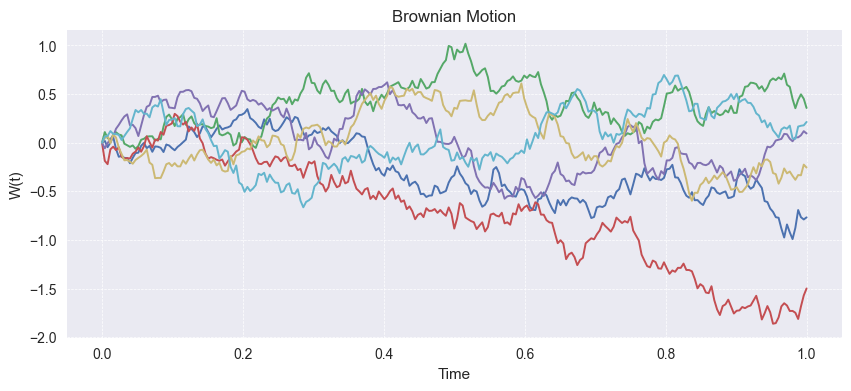

In [3]:
def simulate_brownian_motion_impl(
    n_steps: int,
    horizon: float = 1.0,
    n_paths: int = 1,
    start: float = 0.0,
    seed: int | None = None,
) -> np.ndarray:
    dt = horizon / n_steps
    rng = np.random.default_rng(seed)
    increments = rng.normal(loc=0.0, scale=np.sqrt(dt), size=(n_paths, n_steps))
    cumulative = np.cumsum(increments, axis=1)
    start_col = np.full((n_paths, 1), float(start))
    return np.concatenate([start_col, float(start) + cumulative], axis=1)


n_steps = 252
horizon = 1.0
time_axis = np.linspace(0.0, horizon, n_steps + 1)
bm_paths = simulate_brownian_motion_impl(
    n_steps=n_steps,
    horizon=horizon,
    n_paths=6,
    seed=42,
)

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(bm_paths.shape[0]):
    ax.plot(time_axis, bm_paths[i], linewidth=1.4)
ax.set_title("Brownian Motion")
ax.set_xlabel("Time")
ax.set_ylabel("W(t)")
ax.grid(True, linestyle="--", linewidth=0.5)
plt.show()


## 3) Geometric Brownian Motion (GBM)

SDE:

$$
\frac{dS(t)}{S(t)} = \alpha dt + \sigma dW(t).
$$

Discretized log-return form:

$$
\Delta\log S \approx \left(\alpha-\frac{1}{2}\sigma^2\right)\Delta t + \sigma\sqrt{\Delta t}Z,\quad Z\sim\mathcal{N}(0,1).
$$

Implementation principle: simulate log increments first, then exponentiate cumulative logs.

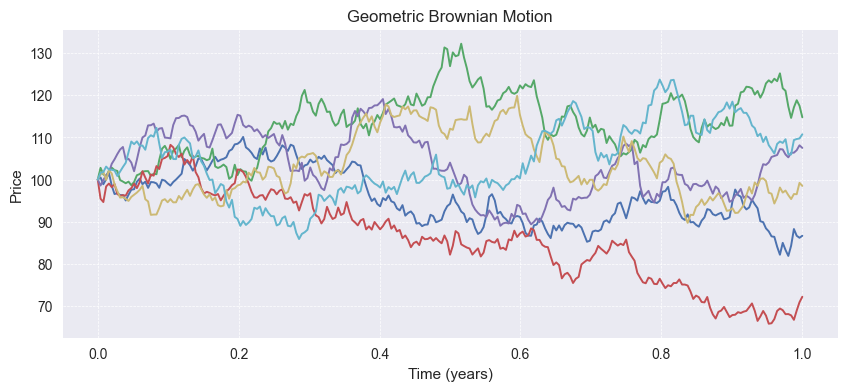

In [4]:
def simulate_gbm_impl(
    n_steps: int,
    horizon: float = 1.0,
    n_paths: int = 1,
    s0: float = 1.0,
    drift: float = 0.0,
    volatility: float = 0.2,
    seed: int | None = None,
) -> np.ndarray:
    dt = horizon / n_steps
    rng = np.random.default_rng(seed)
    z = rng.normal(loc=0.0, scale=1.0, size=(n_paths, n_steps))
    log_inc = (drift - 0.5 * volatility**2) * dt + volatility * np.sqrt(dt) * z
    log_paths = np.cumsum(log_inc, axis=1)
    base = np.zeros((n_paths, 1), dtype=float)
    return s0 * np.exp(np.concatenate([base, log_paths], axis=1))


gbm_paths = simulate_gbm_impl(
    n_steps=252,
    horizon=1.0,
    n_paths=6,
    s0=100.0,
    drift=0.08,
    volatility=0.25,
    seed=42,
)

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(gbm_paths.shape[0]):
    ax.plot(time_axis, gbm_paths[i], linewidth=1.4)
ax.set_title("Geometric Brownian Motion")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Price")
ax.grid(True, linestyle="--", linewidth=0.5)
plt.show()


## 4) Drift and Volatility Estimation

Define log return:

$$
r_j = \log\left(\frac{S_{t_{j+1}}}{S_{t_j}}\right).
$$

Under GBM:

$$
\mathbb{E}[r_j]=\left(\alpha-\frac{1}{2}\sigma^2\right)\Delta t,\qquad
\mathrm{Var}(r_j)=\sigma^2\Delta t.
$$

Implementation principle: estimate sample mean/variance of log returns, then invert formulas for $\alpha$ and $\sigma$.

Data used here: real AAPL monthly closes for 2024 (source: Yahoo Finance).
Loaded via `fetch_close_prices("AAPL", fallback="builtin")` -- no internet connection required.
Use `dt = 1/12` (one month per step) for annualised parameter estimates.

Symbol: AAPL  |  12 monthly data points (2024)
Estimated annualised drift (alpha):       0.356
Estimated annualised volatility (sigma):  0.1833


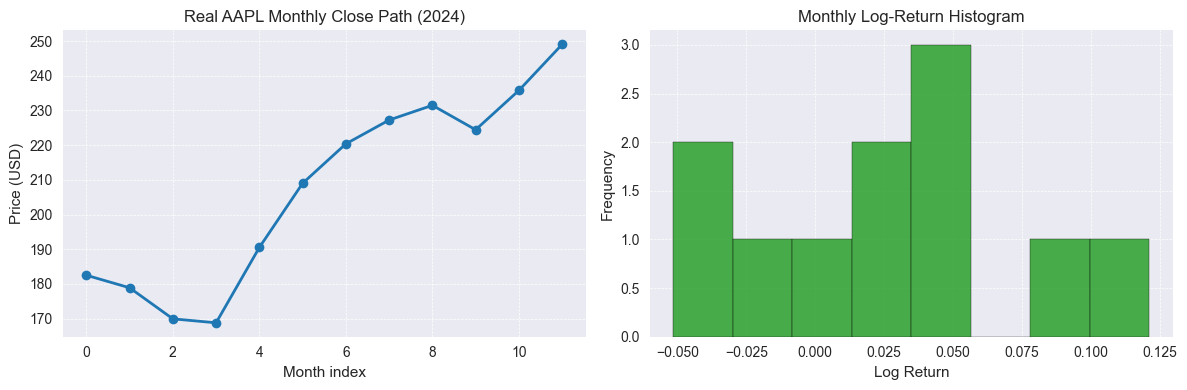

In [5]:
def estimate_drift_and_volatility_impl(
    prices: np.ndarray,
    dt: float,
) -> tuple[float, float]:
    """Return (alpha, sigma) annualised drift and volatility from price series."""
    arr = np.asarray(prices, dtype=float)
    returns = np.diff(np.log(arr))
    mean_r = float(np.mean(returns))
    var_r = float(np.var(returns, ddof=1))
    sigma2 = max(var_r / dt, 0.0)
    sigma = float(np.sqrt(sigma2))
    alpha = float(mean_r / dt + 0.5 * sigma2)
    return alpha, sigma


# Built-in data: AAPL monthly closes 2024 (no internet needed)
symbol = "AAPL"
dt = 1 / 12   # monthly data -> annualise over 12 months

prices = fetch_close_prices(symbol, fallback="builtin")
alpha, sigma = estimate_drift_and_volatility_impl(prices=prices, dt=dt)
returns = np.diff(np.log(prices))

print(f"Symbol: {symbol}  |  {prices.size} monthly data points (2024)")
print("Estimated annualised drift (alpha):      ", round(alpha, 4))
print("Estimated annualised volatility (sigma): ", round(sigma, 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(prices.size), prices, color="tab:blue", linewidth=2.0, marker="o")
axes[0].set_title(f"Real {symbol} Monthly Close Path (2024)")
axes[0].set_xlabel("Month index")
axes[0].set_ylabel("Price (USD)")
axes[0].grid(True, linestyle="--", linewidth=0.5)

axes[1].hist(returns, bins=8, color="tab:green", alpha=0.85, edgecolor="black")
axes[1].set_title("Monthly Log-Return Histogram")
axes[1].set_xlabel("Log Return")
axes[1].set_ylabel("Frequency")
axes[1].grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


## 3b) GBM Calibrated to Real Market Data

The previous GBM simulation used **hand-picked** parameters ($\alpha=0.08$, $\sigma=0.25$).
A more grounded approach is:

1. **Estimate** $\alpha$ and $\sigma$ from a real stock's historical prices (Section 4).
2. **Simulate** GBM paths using those calibrated parameters.
3. **Compare** the simulated paths against the actual historical path.

This connects the mathematical model to real market behaviour and lets us judge
how well GBM captures the true dynamics of the stock.

> **Data note:** Uses `fallback="builtin"` (AAPL monthly closes 2024,
> `dt = 1/12`). No internet connection required.
> `simulate_gbm_impl` defined above -- no new model code is needed.

Calibrated from AAPL (2024 monthly closes):
  alpha (annualised drift):      0.3560
  sigma (annualised volatility): 0.1833


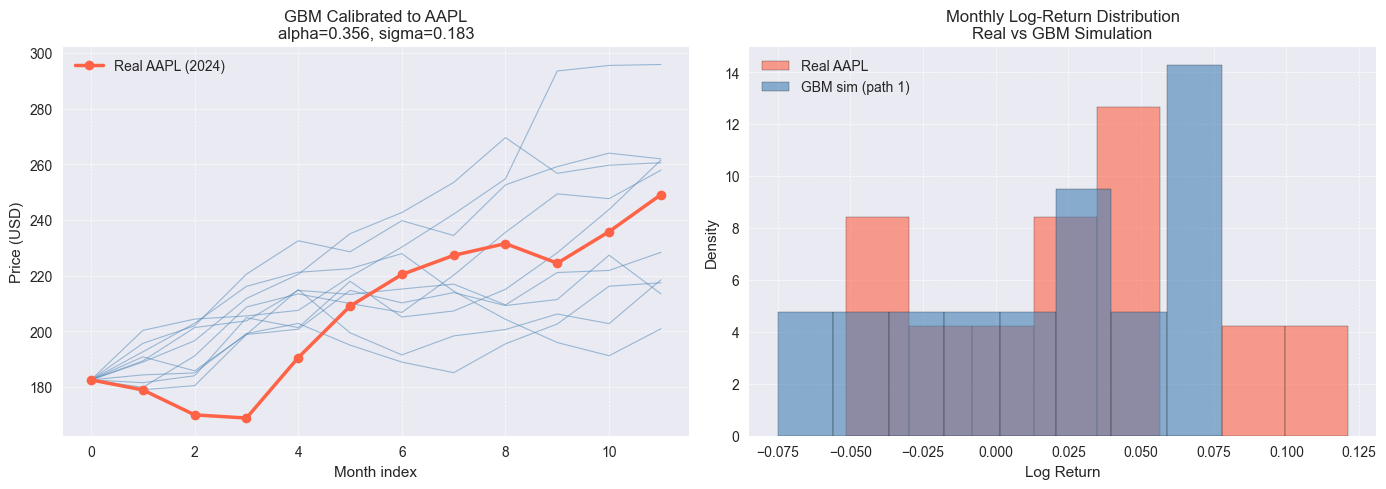


Monthly log-return comparison:
  Real  mean: 0.028265  std: 0.050459
  GBM   mean: 0.016352  std: 0.048358

Note: GBM assumes log-returns are i.i.d. normal.
Any fat tails or skew in the real histogram reveals model limitations.


In [6]:
# --- Step 1: fetch real closing prices (builtin, no network needed) ---
symbol = "AAPL"
dt = 1 / 12   # monthly data

prices_real = fetch_close_prices(symbol, fallback="builtin")
n_real = prices_real.size
s0_real = float(prices_real[0])

# --- Step 2: calibrate GBM parameters from real data ---
drift_real, vol_real = estimate_drift_and_volatility_impl(prices=prices_real, dt=dt)
print(f"Calibrated from {symbol} (2024 monthly closes):")
print(f"  alpha (annualised drift):      {drift_real:.4f}")
print(f"  sigma (annualised volatility): {vol_real:.4f}")

# --- Step 3: simulate GBM paths with calibrated parameters ---
# horizon = (n_real-1) months expressed in years
n_sim_paths = 10
gbm_calibrated = simulate_gbm_impl(
    n_steps=n_real - 1,
    horizon=(n_real - 1) / 12,
    n_paths=n_sim_paths,
    s0=s0_real,
    drift=drift_real,
    volatility=vol_real,
    seed=42,
)

# --- Step 4: compare real path vs calibrated simulations ---
month_axis = np.arange(n_real)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlay simulated paths on real price path
for i in range(n_sim_paths):
    axes[0].plot(month_axis, gbm_calibrated[i], color="steelblue",
                 linewidth=0.8, alpha=0.5)
axes[0].plot(month_axis, prices_real, color="tomato", linewidth=2.5,
             marker="o", label=f"Real {symbol} (2024)")
axes[0].set_title(
    f"GBM Calibrated to {symbol}\n"
    f"alpha={drift_real:.3f}, sigma={vol_real:.3f}"
)
axes[0].set_xlabel("Month index")
axes[0].set_ylabel("Price (USD)")
axes[0].legend()
axes[0].grid(True, linestyle="--", linewidth=0.5)

# Right: log-return distribution -- real vs one simulated path
real_returns = np.diff(np.log(prices_real))
sim_returns = np.diff(np.log(gbm_calibrated[0]))

axes[1].hist(real_returns, bins=8, alpha=0.6, color="tomato",
             edgecolor="black", label=f"Real {symbol}", density=True)
axes[1].hist(sim_returns, bins=8, alpha=0.6, color="steelblue",
             edgecolor="black", label="GBM sim (path 1)", density=True)
axes[1].set_title("Monthly Log-Return Distribution\nReal vs GBM Simulation")
axes[1].set_xlabel("Log Return")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].grid(True, linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

# --- goodness-of-fit summary ---
print("\nMonthly log-return comparison:")
print(f"  Real  mean: {real_returns.mean():.6f}  std: {real_returns.std():.6f}")
print(f"  GBM   mean: {sim_returns.mean():.6f}  std: {sim_returns.std():.6f}")
print("\nNote: GBM assumes log-returns are i.i.d. normal.")
print("Any fat tails or skew in the real histogram reveals model limitations.")

## 5) Jump Diffusion

Merton-style discrete form:

$$
\Delta \log S \approx \left(\alpha - \frac{1}{2}\sigma^2 - \lambda\kappa\right)\Delta t
 + \sigma\sqrt{\Delta t}Z + J_{\Delta t},
$$

where jump counts satisfy

$$
N_{\Delta t} \sim \mathrm{Poisson}(\lambda \Delta t).
$$

Implementation principle:
- simulate diffusion term and jump term separately
- use drift compensation $-\lambda\kappa$ to control expected growth

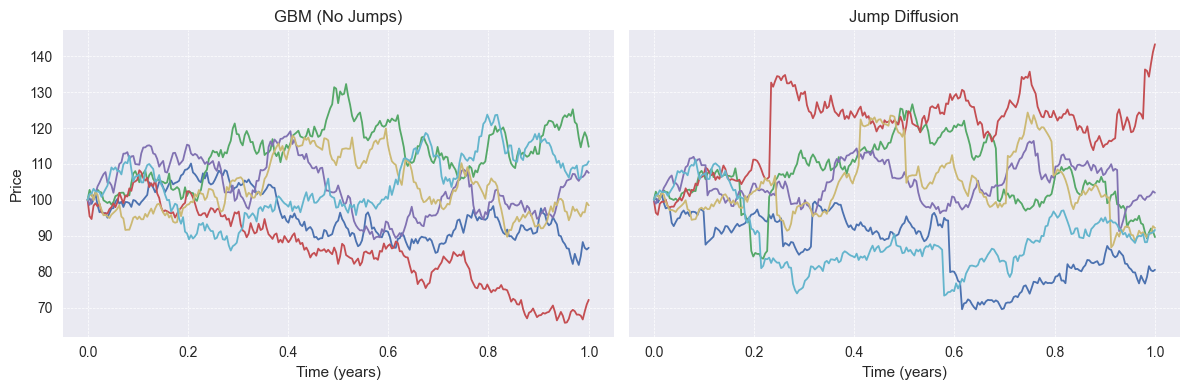

In [7]:
def simulate_jump_diffusion_impl(
    n_steps: int,
    horizon: float = 1.0,
    n_paths: int = 1,
    s0: float = 1.0,
    drift: float = 0.0,
    volatility: float = 0.2,
    jump_intensity: float = 1.0,
    jump_mean: float = 0.0,
    jump_std: float = 0.1,
    seed: int | None = None,
) -> np.ndarray:
    dt = horizon / n_steps
    rng = np.random.default_rng(seed)

    z = rng.normal(loc=0.0, scale=1.0, size=(n_paths, n_steps))
    diffusion = volatility * np.sqrt(dt) * z

    n_jumps = rng.poisson(lam=jump_intensity * dt, size=(n_paths, n_steps))
    jump_scale = np.sqrt(n_jumps.astype(float)) * jump_std
    jump_component = rng.normal(loc=n_jumps * jump_mean, scale=jump_scale)

    kappa = np.exp(jump_mean + 0.5 * jump_std**2) - 1.0
    drift_adjusted = drift - 0.5 * volatility**2 - jump_intensity * kappa

    log_inc = drift_adjusted * dt + diffusion + jump_component
    log_paths = np.cumsum(log_inc, axis=1)
    base = np.zeros((n_paths, 1), dtype=float)
    return s0 * np.exp(np.concatenate([base, log_paths], axis=1))


jump_paths = simulate_jump_diffusion_impl(
    n_steps=252,
    horizon=1.0,
    n_paths=6,
    s0=100.0,
    drift=0.08,
    volatility=0.20,
    jump_intensity=6.0,
    jump_mean=-0.03,
    jump_std=0.10,
    seed=42,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for i in range(gbm_paths.shape[0]):
    axes[0].plot(time_axis, gbm_paths[i], linewidth=1.3)
for i in range(jump_paths.shape[0]):
    axes[1].plot(time_axis, jump_paths[i], linewidth=1.3)

axes[0].set_title("GBM (No Jumps)")
axes[1].set_title("Jump Diffusion")
for ax in axes:
    ax.set_xlabel("Time (years)")
    ax.grid(True, linestyle="--", linewidth=0.5)
axes[0].set_ylabel("Price")
plt.tight_layout()
plt.show()


## Closing Notes

This notebook intentionally emphasizes implementation principles:

- vectorized simulation over many paths
- explicit mapping from equations to code variables
- parameter validation and reproducibility

For package-level reusable APIs, see `src/quant_edu/asset_price_modeling/`.